11490434/11490434 [==============================] - 2s 0us/step
Epoch 1/5
1875/1875 [==============================] - 24s 5ms/step - loss: 0.1447 - accuracy: 0.9542 - val_loss: 0.0539 - val_accuracy: 0.9807
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0482 - accuracy: 0.9851 - val_loss: 0.0375 - val_accuracy: 0.9868
Epoch 3/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0342 - accuracy: 0.9887 - val_loss: 0.0437 - val_accuracy: 0.9864
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0258 - accuracy: 0.9916 - val_loss: 0.0394 - val_accuracy: 0.9880
Epoch 5/5
313/313 [==============================] - 1s 3ms/step - loss: 0.0409 - accuracy: 0.9885

정확도 평가결과: 98.85 % 



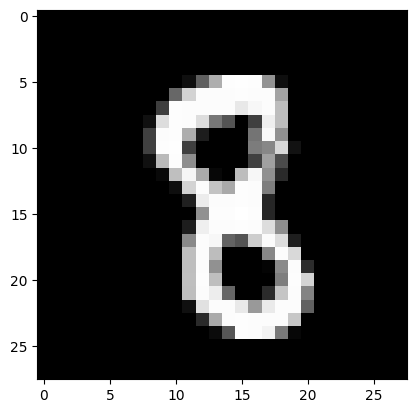

1/1 [==============================] - 0s 149ms/step


 이 그림은 무슨 글자이지? 
 ==> AI가 예측한 답 : 8


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import random

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(625, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# 테스트 데이터셋으로 모델 성능 평가하기
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n정확도 평가결과: {format(test_acc*100, '4.2f')} % \n")

# 예제 그림 띄워보기
r = random.randint(0, 9999)
plt.imshow(x_test[r], cmap='gray')
plt.show()

# 예제 그림 맞추기
example_image = x_test[r]
example_image = np.expand_dims(example_image, axis=0)  # Add an extra dimension for batch
predictions = model.predict(example_image)
predicted_class = np.argmax(predictions[0])
print(f"\n\n 이 그림은 무슨 글자이지? \n ==> AI가 예측한 답 : {predicted_class}")

